## 二元词模型：只给一个字符，并预测下一个字符

In [1]:
from turtledemo.chaos import plot
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
words[:10]

32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

### 先给出word中 二元字符的组合

In [18]:
## 巧妙的方式去获取二元字符组
## 获取数据集中所有二元字符组的次数
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']  # 添加开始结束字符
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [22]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [23]:
import torch

In [40]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [41]:
chars = sorted(list(set(''.join(words))))

stoi = {s: i + 1 for i, s in enumerate(chars)}

stoi['.'] = 0

itos = {i: s for s, i in stoi.items()}


## 把二元组映射到tensor， 行是第一个字符，列是第二个字符
## 使用<S> <E> 作为最后的元素展示不太好看， 变换成 . = 0 可视化好看一些， 但 <S> = 0 <E> = 27 同样能够达到目标功能

In [42]:
for w in words:
    chs = ['.'] + list(w) + ['.']  # 添加开始结束字符
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

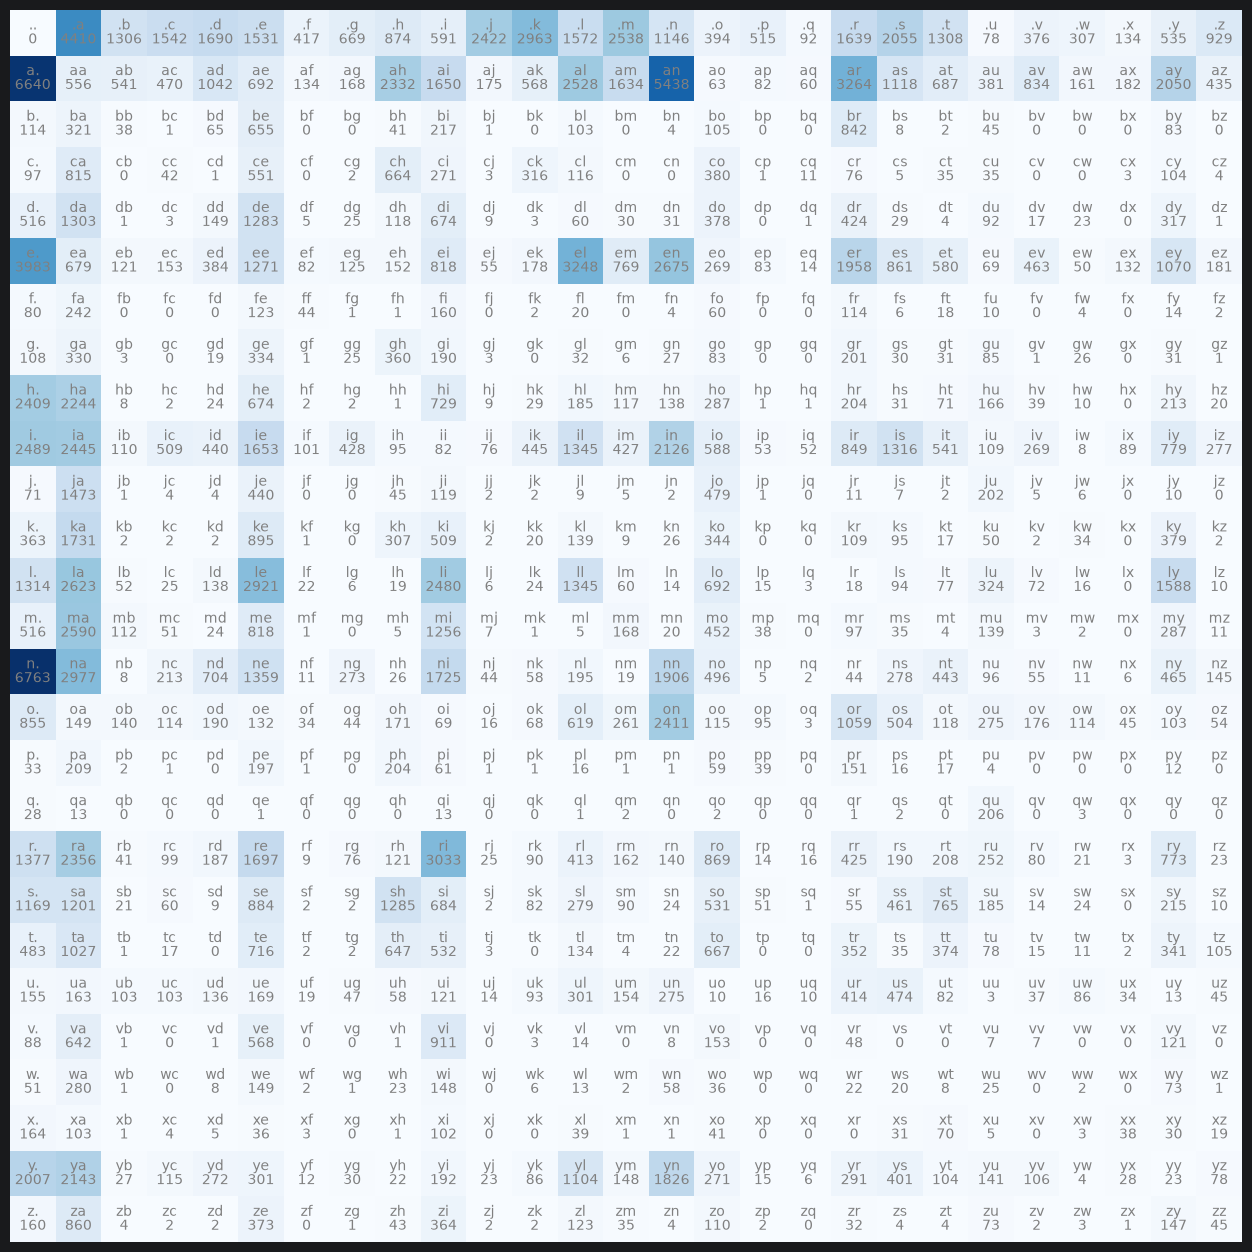

In [43]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')

- 使用torch.mutltinomail函数来按照概率权重采样，当得到一群数据的概率分布，如果希望按照这个概率分布来采样这批数据，就可以使用这个函数，
- 在二元组模型中，当知道前一个字符，通过数据集统计的以该字符开头的二元组统计结果和概率分布是知道，因此可以按照这个权重来采样已实现预测的效果

In [57]:
P = N.float()

### 注意广播的对齐性质，如果size缺维度时，那么会先向右对齐，在复制元素，keepdim就是保证sum前后的shape的维度不变，避免按行求和时，在进行广播时，误认为为按列求和，导致计算错混
P = P / P.sum(1, keepdim=True)

In [61]:
for _ in range(100):
    idx = 0
    out = []
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True).item()
        out += list(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

iganzieladriyi.
kanan.
amal.
ar.
a.
a.
leemonaneviarthah.
z.
enttymiliajemamiezariligyn.
lophan.
aradereukanavenayod.
rela.
hio.
mealyla.
a.
sieson.
t.
gin.
jariaceva.
tavalalajalahrvinaso.
r.
sst.
tydolya.
adonin.
fia.
ckas.
aklissimi.
gislezy.
camys.
ten.
je.
jah.
z.
ars.
n.
mchietennescayin.
naleyresiquidrrmauwetinafeee.
a.
mo.
mse.
leligue.
tishana.
moncitio.
o.
ba.
masila.
ddith.
enani.
aruweeler.
mach.
menes.
nn.
zarema.
mbribeleamilia.
fa.
ar.
leac.
bamaha.
javonirolie.
tounaraux.
jostthymolanays.
move.
t.
rajay.
deviaisilerexiayahehadinowallemdrabsthariaresayrerollaconada.
caicen.
ma.
j.
d.
diembi.
veenahey.
hyn.
yakaidama.
xan.
digeeereianillalorirvig.
fineonnov.
desa.
ema.
cholighidalosh.
aidavalfala.
manyl.
remr.
nnea.
chd.
nelir.
ma.
ton.
jama.
ty.
d.
go.
dyamia.
ros.
min.
n.
jaelylie.
rozamath.
rahen.
narainnlen.
ke.


- 当模型构建之后，如何评价模型的精度，如果寻找损失和能够使损失下降的参数成为首要目标
- 当前这个二元组模型，使用似然来表示精度最为合适，多个条件同时成立的似然表示，但多个概率相乘必然得到很小的值，不是正常的损失值
- 因此 使用对数似然求和替代 -> 对数函数是x越大，y越接近0，反之越接近负无穷 -> 因此取负对数符合我们常见的损失的表达方式


##  使用pytorch 来实现这个过程

- 为什么神经网络的二元模型，同样在预测之后也要随机采样，那是因为 训练的参数是下一个字符的概率分布，不是某一个字符的概率值
- 使用随机采样也是为了保证结果的不唯一性

In [75]:
# 制作二元组的训练集

xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

# Tensor 实例化是 float32 tensor 实例化是 int64
xs = torch.tensor(xs)
ys = torch.tensor(ys)

xs.shape


torch.Size([5])

In [81]:
# 把输入encoder one-hot（独热编码） 向量
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()


In [90]:
W = torch.randn(27, 27, requires_grad=True)

logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [91]:
W.grad = None
loss.backward()

### 原地修改叶子变量，会导致计算图出现问题，使用no_grad函数可以告知参数的更新不进入计算图中
### 也可以将待优化参数绑定在优化器中，优化器统一优化
with torch.no_grad():
    W += -50 * W.grad

/home/x/deepnet-zero-hero/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.